<a href="https://colab.research.google.com/github/stenoe/ABSmultisite/blob/main/example/scripts/ABSmultisite_example_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python notebook example ABS multisite course

## Load data from the github repo

In [1]:
import pandas as pd

# Replace this with your raw GitHub CSV URL
# Note: Use the 'Raw' button on GitHub to get the correct link format (usually starting with raw.githubusercontent.com)
url = 'https://raw.githubusercontent.com/stenoe/ABSmultisite/refs/heads/main/example/data/ozone_daily_median.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(url)

# Display the first few rows of the DataFrame
df.head()

,year,doy,o3
0,2018,1,14.661500
1,2018,2,26.131167
2,2018,3,23.183333
3,2018,4,14.575667
4,2018,5,20.003167


## Import missing libraries

In [2]:
!pip install pymannkendall

## perform a time series decomposotion

Removing spikes outside [0.621, 48.716] ppb
Removed 2 outliers out of 365 points


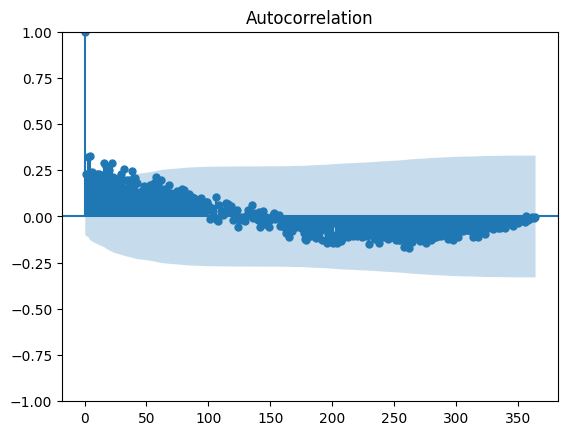

                           GLSAR Regression Results                           
Dep. Variable:                      y   R-squared:                       0.053
Model:                          GLSAR   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     20.30
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           8.94e-06
Time:                        08:31:00   Log-Likelihood:                -1048.1
No. Observations:                 364   AIC:                             2100.
Df Residuals:                     362   BIC:                             2108.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.5027      1.923     16.902      0.0

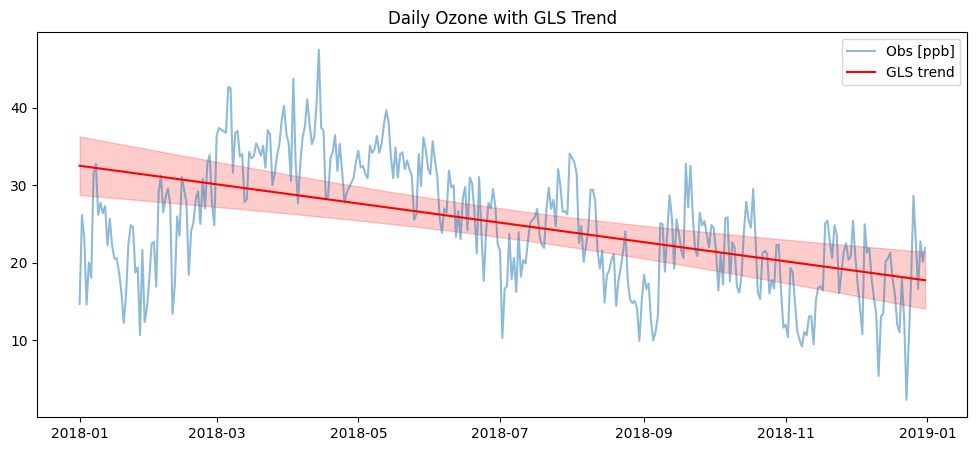

/tmp/ipykernel_3570/3694141146.py:90: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomposition = seasonal_decompose(dfc['o3'], model='additive', period=365, extrapolate_trend='freq')


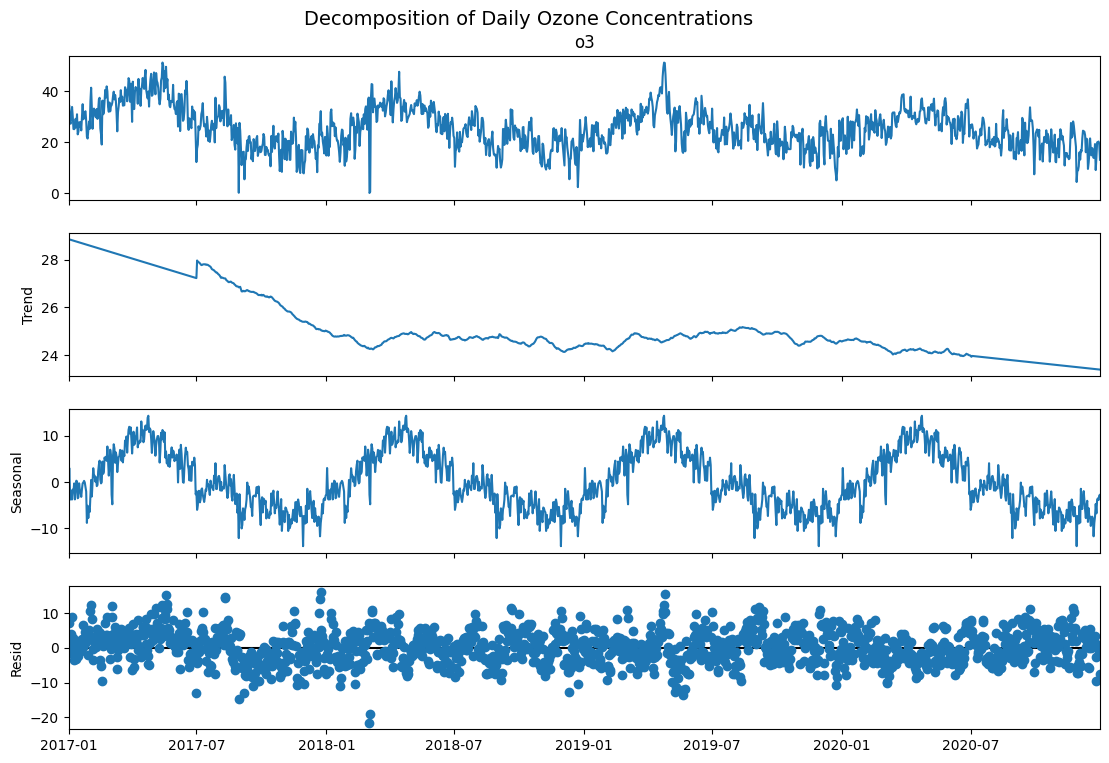

In [7]:
# -------------------------------------------------
# 0️⃣ Packages
# -------------------------------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import pymannkendall as mk
# -------------------------------------------------
# 1️⃣ Load & clean
# -------------------------------------------------
# df = pd.read_csv('ozone_daily_median.csv') # already loaded from github!
df = df[df.year == 2018].copy() # replace for other years
df['date'] = pd.to_datetime(df.year, format='%Y') + pd.to_timedelta(df.doy - 1, unit='d')
df.set_index('date', inplace=True)
df['ozone_ppb'] = df['o3'].interpolate(method='time')
# -------------------------------------------------
# 1.1 Spike removal (remove outliers)
# -------------------------------------------------
# Remove values outside mean ± 3*std
mean_val = df['ozone_ppb'].mean()
std_val = df['ozone_ppb'].std()
lower_bound = mean_val - 3 * std_val
upper_bound = mean_val + 3 * std_val

print(f"Removing spikes outside [{lower_bound:.3f}, {upper_bound:.3f}] ppb")
mask = (df['ozone_ppb'] >= lower_bound) & (df['ozone_ppb'] <= upper_bound)
print(f"Removed {(~mask).sum()} outliers out of {len(df)} points")

df.loc[~mask, 'ozone_ppb'] = np.nan
df['ozone_ppb'] = df['ozone_ppb'].interpolate(method='time')

# -------------------------------------------------
# 2️⃣ STL decomposition
# -------------------------------------------------
stl = STL(df['ozone_ppb'], period=365, robust=True)
res = stl.fit()
trend = res.trend
seasonal = res.seasonal
resid = res.resid
# -------------------------------------------------
# 3️⃣ Check autocorrelation
# -------------------------------------------------
sm.graphics.tsa.plot_acf(resid, lags=364); plt.show()
# -------------------------------------------------
# 4️⃣ GLS with AR(1) errors
# -------------------------------------------------
t = np.arange(len(df))
X = sm.add_constant(t)
gls = sm.GLSAR(df['ozone_ppb'].values, X, rho=1)
gls_res = gls.iterative_fit(maxiter=10)
print(gls_res.summary())
# -------------------------------------------------
# 5️⃣ Mann‑Kendall (on original series)
# -------------------------------------------------
mkt = mk.original_test(df['ozone_ppb'], alpha=0.05)
print(f"MK trend: {mkt.trend}, p={mkt.p:.3f}, slope={mkt.slope:.4e}")

# -------------------------------------------------
# 6️⃣ Plot
# -------------------------------------------------
fitted = X @ gls_res.params
ci = gls_res.get_prediction().conf_int(alpha=0.05)

plt.figure(figsize=(12,5))
plt.plot(df.index, df['ozone_ppb'], label='Obs [ppb]', alpha=0.5)
plt.plot(df.index, fitted, color='red', label='GLS trend')
plt.fill_between(df.index, ci[:,0], ci[:,1], color='red', alpha=0.2)
plt.title('Daily Ozone with GLS Trend')
plt.legend()
plt.show()

# -------------------------------------------------
# 7️⃣ Decomposition (additive)
# -------------------------------------------------
from statsmodels.tsa.seasonal import seasonal_decompose

# dfc = pd.read_csv('Ozone_daily_all.csv') # for decomposition
url = "https://raw.githubusercontent.com/stenoe/ABSmultisite/refs/heads/main/example/data/Ozone_daily_all.csv"
dfc = pd.read_csv(url)
dfc = dfc[dfc.year > 2016].copy()
dfc['date'] = pd.to_datetime(dfc.year, format='%Y') + pd.to_timedelta(dfc.doy - 1, unit='d')
dfc.set_index('date', inplace=True)
# print(dfc.head())

# Set a regular daily frequency and fill missing values using forward fill
dfc = dfc.asfreq('D')
dfc['o3'] = dfc['o3'].ffill()

# Decompose the daily series (365-day seasonality for yearly patterns)
decomposition = seasonal_decompose(dfc['o3'], model='additive', period=365, extrapolate_trend='freq')

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Decomposition of Daily Ozone Concentrations', fontsize=14)
#plt.tight_layout()
# plt.grid()
plt.show()